# Load imports

In [96]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json

# GeoJSON Files (Loaded with GeoPandas)
GeoJSON files contain geometry (points, lines, or polygons).
These datasets must be loaded with GeoPandas because I need their shapes for:

Spatial joins

Mapping

Neighborhood aggregation

Calculating zoning intensity by area

### 1. Zoning (GeoJSON)
Contains polygon geometries for zoning districts.

Required for spatial joins with parcels and subareas.

Used to calculate redevelopment potential.

### 2. Parcels (GeoJSON)
Contains parcel boundary polygons.

Needed to attach zoning to parcels and neighborhoods.

Supports parcel‑level spatial analysis.

### 3. Community Planning Areas / Subareas (GeoJSON)
Contains neighborhood boundary polygons.

Used as the geographic unit for aggregating all metrics.

Essential for spatial joins with zoning and permits.

In [2]:
# Load spatial datasets
zoning = gpd.read_file("../data/Zoning_Vw_-3635171973256313343 (1).geojson")

In [3]:
parcels = gpd.read_file("../data/Parcels_view_-4743305439210361335.geojson")

In [4]:
subareas = gpd.read_file("../data/Community_Planning_Areas_(Subareas)_.geojson")

# CSV Files (Loaded with pandas → Converted to GeoPandas)
CSV files contain tabular attributes, but in this project the permit datasets also include latitude and longitude.
We load them with pandas first, then convert them into GeoDataFrames so we can:

Map permit locations

Join permits to neighborhoods

Calculate permit density

Integrate them into the Neighborhood Transformation Index

### 4. Building Permits (CSV)
Stored as a table with permit details and lat/lng.

Converted into point geometry for spatial joins.

CSV version is cleaner and faster to load than the GeoJSON version.

### 5. Permit Applications (CSV)
Same structure as issued permits.

Includes lat/lng for spatial conversion.

Used to measure pipeline development activity.

In [5]:
# Load tabular datasets
permits = pd.read_csv("../data/Building_Permits_Issued_2_-3206176320106085339.csv")
applications = pd.read_csv("../data/Building_Permit_Applications_Feature_Layer_view_-3134924856831433637.csv")

# Inspecting the data

In [6]:
zoning.head()

,OBJECTID,ORD_DATE,CASE_NO,ORDINANCE,ZONE_DESC,NAME,GlobalID,geometry
0,1,"Tue, 24 Dec 1974 06:00:00 GMT",None,O73-650,CS,None,9c132ca3-3efc-4094-9825-bf3c935267ab,"POLYGON ((-86.87487 36.28165, -86.87468 36.281..."
1,2,"Thu, 01 Jan 1998 06:00:00 GMT",,O96-555,CS,None,18741a88-dae7-4fa0-b13a-a246e8fc3b04,"POLYGON ((-86.80117 36.27836, -86.80038 36.277..."
2,3,"Tue, 24 Dec 1974 06:00:00 GMT",,O73-650,R15,None,7b22f667-a035-4e47-a3d2-5aa0bbd72241,"POLYGON ((-86.80425 36.28038, -86.80438 36.279..."
3,4,"Thu, 28 May 2009 05:00:00 GMT",2009Z-012PR-001,BL2009-424,AR2A,None,758fcde4-6aac-47bc-b3dc-8504bd5eae73,"POLYGON ((-86.77879 36.29175, -86.77882 36.291..."
4,5,"Sat, 24 May 2003 05:00:00 GMT",2003Z-020G-02,BL2003-1393,R20,None,1641774a-7384-4a3d-9212-bf52426608db,"POLYGON ((-86.79217 36.27773, -86.79228 36.277..."


In [7]:
parcels.head()

,OBJECTID,STANPAR,FEATURETYPE,FLOORNUMBER,ParID,Tract,Council,TaxDist,Owner,OwnDate,...,IsRegular,LUCode,LUDesc,LandAppr,ImprAppr,TotlAppr,Zoning,Lat,Lon,geometry
0,1,110010A00200CO,Condo,None,455505.0,37015610,12,GSD,"BELEW, STEPHEN JOSEPH","Fri, 08 Sep 2023 05:00:00 GMT",...,N,015,RESIDENTIAL CONDO,95200.0,376400.0,471600.0,SP,36.148727,-86.580355,"POLYGON ((-86.58036 36.14877, -86.58035 36.148..."
1,2,083010O90000CO,Common Area,None,455507.0,37011700,05,USD,O.I.C. TENFIFTYONE PETWAY AVENUE,"Thu, 22 Jul 2021 05:00:00 GMT",...,N,010,VACANT RESIDENTIAL LAND,100.0,0.0,100.0,RS5,36.187147,-86.747849,"POLYGON ((-86.74769 36.18747, -86.74778 36.186..."
2,3,114040A06500CO,Condo,None,455508.0,37018301,35,GSD,"MCCLELLAND, JASON & DANIELLE","Tue, 05 Dec 2023 06:00:00 GMT",...,N,010,VACANT RESIENTIAL LAND,90000.0,346000.0,436000.0,SP,36.120900,-86.920964,"POLYGON ((-86.92101 36.12094, -86.92090 36.120..."
3,4,114040A06300CO,Condo,None,455509.0,37018301,35,GSD,"HO, JUI-LIEN CHOU","Fri, 08 Dec 2023 06:00:00 GMT",...,N,010,VACANT RESIDENTIAL LAND,90000.0,346000.0,436000.0,SP,36.120855,-86.920987,"POLYGON ((-86.92103 36.12090, -86.92092 36.120..."
4,5,114040A06400CO,Condo,None,455512.0,37018301,35,GSD,"SILVERMAN, GREG","Thu, 05 Sep 2024 05:00:00 GMT",...,N,010,VACANT RESIDENTIAL LAND,90000.0,349500.0,439500.0,SP,36.120886,-86.921480,"POLYGON ((-86.92140 36.12089, -86.92142 36.120..."


In [8]:
subareas.head()

,OBJECTID,CommunityNumber,CommunityName,GlobalID,geometry
0,1,2,Parkwood - Union Hill,baa3fada-cf8c-4384-899e-b296a3f0d634,"POLYGON ((-86.75375 36.40431, -86.75362 36.404..."
1,2,1,Joelton,57192bac-4b35-433e-9a57-0eb4e23f8ca0,"POLYGON ((-86.90741 36.39053, -86.90728 36.390..."
2,3,4,Madison,68911bc4-caf0-4d28-bc9f-c64c27a530fb,"POLYGON ((-86.66885 36.30088, -86.67049 36.301..."
3,4,3,Bordeaux - Whites Creek - Haynes Trinity,1112fbc3-285c-4c29-b548-11223136195e,"POLYGON ((-86.81409 36.30151, -86.81326 36.300..."
4,5,14,Donelson - Hermitage - Old Hickory,4c9ba617-436b-45be-8d80-0740d86a4809,"POLYGON ((-86.58100 36.20931, -86.58109 36.208..."


In [9]:
permits.head()

,Permit #,Permit Type Description,Permit Subtype Description,Parcel,Date Entered,Date Issued,Construction Cost,Address,City,State,...,IVR Tracking,Purpose,Council District,Census Tract,Longitude,Latitude,ObjectId,Zip Code,x,y
0,2019067389,Building Use & Occupancy,"Multifamily, Tri-Plex, Quad, Apartments",05100017300,11/4/2019 6:00:00 AM,4/4/2023 5:00:00 AM,1,600 CREATIVE WAY,MADISON,TN,...,3728777,MASTER PERMIT ONLY NO CONSTRUCTION THIS PERMIT...,5.0,37010802,-86.740236,36.243639,1,37115,-9.655879e+06,4.334198e+06
1,2020006147,Building Residential - New,Single Family Residence,00800026100,1/28/2020 6:00:00 AM,4/21/2023 5:00:00 AM,178132,4168 BAXTER RD,JOELTON,TN,...,3754519,To construct a new single family residence wit...,1.0,37010103,-86.907892,36.364056,2,37080,-9.674542e+06,4.350831e+06
2,2020008205,Building Residential - New,Single Family Residence,05308013800,2/6/2020 6:00:00 AM,7/19/2023 5:00:00 AM,734113,410 30TH ST,OLD HICKORY,TN,...,3757502,12/28/2020 Applicant is submitting revised ele...,11.0,37010502,-86.635039,36.248312,3,37138,-9.644168e+06,4.334843e+06
3,2020037584,Building Commercial - Rehab,Day Care Center (Up To 75) - Child Care,05106006200,6/17/2020 5:00:00 AM,4/9/2024 5:00:00 AM,82455,1022 S GRAYCROFT AVE,MADISON,TN,...,3837660,parcel is zoned RM9 and RS20 and contains 11.1...,3.0,37010802,-86.736233,36.252179,4,37115,-9.655433e+06,4.335376e+06
4,2020050957,Building Residential - New,"Accessory Structure, Pools - Residential",11407002600,8/17/2020 5:00:00 AM,4/20/2023 5:00:00 AM,75000,7545 B OAKHAVEN TRCE,NASHVILLE,TN,...,3862490,To install an inground 18x36 sqaure shaped poo...,35.0,37018301,-86.928892,36.118691,5,37209,-9.676880e+06,4.316965e+06


In [10]:
applications.head()

,Permit #,Permit Type Description,Permit Subtype Description,Parcel,Date Entered,Date Issued,Construction Cost,Address,City,State,...,Permit SubType,IVR Tracking,Purpose,Council District,Lon,Lat,ObjectId,Zip Code,x,y
0,D2020047607,Building Use & Occupancy,"Accessory Structure, Pools - Residential",11704002200,10/24/2023 5:00:00 AM,NaN,100000,2509 BELMONT BLVD,NASHVILLE,TN,...,CAA14U017,3856896,Proposed 13' x 32' Swimming Pool in rear yard.,18.0,-86.794539,36.125197,1,37212,-9.661924e+06,4.317862e+06
1,D2021026275,Building Residential - Addition,Single Family Residence,16109004000,8/2/2024 5:00:00 AM,NaN,318761,5500 THALMAN DR,BRENTWOOD,TN,...,CAA01R301,3974584,5500 Thalman Drive,26.0,-86.749685,36.045886,2,37027,-9.656931e+06,4.306937e+06
2,D2023014026,Building Residential - Addition,Single Family Residence,12912005600,3/3/2023 6:00:00 AM,NaN,35984,1001 PERCY WARNER BLVD,NASHVILLE,TN,...,CAA01R301,4279927,To construct a 744 sq ft carport addition to t...,23.0,-86.881114,36.090131,3,37205,-9.671561e+06,4.313030e+06
3,D2023027056,Building Residential - New,"Multifamily, Tri-Plex, Quad, Apartments",09203002900,4/25/2023 5:00:00 AM,NaN,0,2405 E JEFFERSON ST,NASHVILLE,TN,...,CAA03R398,4311444,Permit not required by zoning The work for ...,21.0,-86.813076,36.168483,4,37208,-9.663987e+06,4.323829e+06
4,D2023029429,Building Demolition Permit,Demolition Permit - Residential,06108020400,12/17/2024 6:00:00 AM,NaN,20000,1130 WINDING WAY,NASHVILLE,TN,...,CAZ01A001,4318467,Demo existing home in need of much repairs sit...,7.0,-86.721786,36.226283,5,37216,-9.653825e+06,4.331802e+06


In [11]:
zoning.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   OBJECTID   5937 non-null   int64   
 1   ORD_DATE   5922 non-null   object  
 2   CASE_NO    5829 non-null   object  
 3   ORDINANCE  5925 non-null   object  
 4   ZONE_DESC  5937 non-null   object  
 5   NAME       1015 non-null   object  
 6   GlobalID   5937 non-null   object  
 7   geometry   5932 non-null   geometry
dtypes: geometry(1), int64(1), object(6)
memory usage: 371.2+ KB


In [12]:
parcels.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 285934 entries, 0 to 285933
Data columns (total 43 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   OBJECTID      285934 non-null  int64   
 1   STANPAR       285934 non-null  object  
 2   FEATURETYPE   285934 non-null  object  
 3   FLOORNUMBER   21670 non-null   object  
 4   ParID         285884 non-null  float64 
 5   Tract         285883 non-null  object  
 6   Council       285882 non-null  object  
 7   TaxDist       282812 non-null  object  
 8   Owner         285884 non-null  object  
 9   OwnDate       285883 non-null  object  
 10  SalePrice     227494 non-null  float64 
 11  OwnInstr      285883 non-null  object  
 12  OwnAddr1      285385 non-null  object  
 13  OwnAddr2      75834 non-null   object  
 14  OwnAddr3      75748 non-null   object  
 15  OwnCity       285384 non-null  object  
 16  OwnState      285634 non-null  object  
 17  OwnCountry    285633 

In [13]:
subareas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   OBJECTID         14 non-null     int64   
 1   CommunityNumber  14 non-null     int64   
 2   CommunityName    14 non-null     object  
 3   GlobalID         14 non-null     object  
 4   geometry         14 non-null     geometry
dtypes: geometry(1), int64(2), object(2)
memory usage: 688.0+ bytes


In [14]:
permits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29619 entries, 0 to 29618
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Permit #                    29619 non-null  object 
 1   Permit Type Description     29619 non-null  object 
 2   Permit Subtype Description  29619 non-null  object 
 3   Parcel                      29619 non-null  object 
 4   Date Entered                29619 non-null  object 
 5   Date Issued                 29619 non-null  object 
 6   Construction Cost           29619 non-null  int64  
 7   Address                     29619 non-null  object 
 8   City                        29617 non-null  object 
 9   State                       29619 non-null  object 
 10  Subdivision Lot             29619 non-null  object 
 11  Contact                     29619 non-null  object 
 12  Permit Type                 29619 non-null  object 
 13  Permit SubType              296

In [15]:
applications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5645 entries, 0 to 5644
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Permit #                    5645 non-null   object 
 1   Permit Type Description     5645 non-null   object 
 2   Permit Subtype Description  5645 non-null   object 
 3   Parcel                      5645 non-null   object 
 4   Date Entered                5645 non-null   object 
 5   Date Issued                 0 non-null      float64
 6   Construction Cost           5645 non-null   int64  
 7   Address                     5645 non-null   object 
 8   City                        5644 non-null   object 
 9   State                       5645 non-null   object 
 10  Subdivision Lot             5645 non-null   object 
 11  Contact                     5645 non-null   object 
 12  Permit Type                 5645 non-null   object 
 13  Permit SubType              5645 

# Cleaning up the data!

# ZONING CLEANING

### Step 1 — Load and inspect the zoning dataset  
I’m keeping only the zoning fields I need and standardizing the zoning descriptions.

In [16]:
# Keep only relevant zoning fields
zoning_clean = zoning_clean = zoning[[
    "OBJECTID", "ORD_DATE", "CASE_NO", "ORDINANCE",
    "ZONE_DESC", "NAME", "geometry"
]].copy()

# Standardize zoning descriptions
zoning_clean["ZONE_DESC"] = zoning_clean["ZONE_DESC"].astype(str).str.strip().str.upper()

# Drop rows without geometry
zoning_clean = zoning_clean.dropna(subset=["geometry"])

zoning_clean.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 5932 entries, 0 to 5936
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   OBJECTID   5932 non-null   int64   
 1   ORD_DATE   5917 non-null   object  
 2   CASE_NO    5825 non-null   object  
 3   ORDINANCE  5920 non-null   object  
 4   ZONE_DESC  5932 non-null   object  
 5   NAME       1014 non-null   object  
 6   geometry   5932 non-null   geometry
dtypes: geometry(1), int64(1), object(5)
memory usage: 370.8+ KB


### Step 2 — Convert zoning dates
I’m converting the ordinance date into a proper datetime field.

In [17]:
zoning_clean["ORD_DATE"] = pd.to_datetime(zoning_clean["ORD_DATE"], errors="coerce")

### Step 3 — Confirm zoning CRS
I’m making sure zoning uses EPSG:4326 (the standard identifier for the WGS 84 coordinate reference system {thanks google!}) so it aligns with the rest of the project.

In [18]:
if zoning_clean.crs != "EPSG:4326":
    zoning_clean = zoning_clean.to_crs("EPSG:4326")

# PARCELS CLEANING

### Step 4 — Decide which parcel fields to keep  
I’m keeping the parcel fields that allow me to calculate sale price trends by neighborhood. These include sale price, ownership date, parcel ID, zoning, acreage, and geometry. Everything else can be dropped.

In [19]:
parcels_clean = parcels[[
    "ParID",
    "SalePrice",
    "OwnDate",
    "PropDate",
    "PropZip",
    "Zoning",
    "Acres",
    "geometry"
]].copy()

# Convert dates
parcels_clean["OwnDate"] = pd.to_datetime(parcels_clean["OwnDate"], errors="coerce")
parcels_clean["PropDate"] = pd.to_datetime(parcels_clean["PropDate"], errors="coerce")

# Standardize zoning
parcels_clean["Zoning"] = parcels_clean["Zoning"].astype(str).str.strip().str.upper()

# Drop rows without geometry
parcels_clean = parcels_clean.dropna(subset=["geometry"])

parcels_clean.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 285934 entries, 0 to 285933
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   ParID      285884 non-null  float64       
 1   SalePrice  227494 non-null  float64       
 2   OwnDate    285883 non-null  datetime64[ns]
 3   PropDate   285882 non-null  datetime64[ns]
 4   PropZip    285884 non-null  object        
 5   Zoning     285934 non-null  object        
 6   Acres      285884 non-null  float64       
 7   geometry   285934 non-null  geometry      
dtypes: datetime64[ns](2), float64(3), geometry(1), object(2)
memory usage: 17.5+ MB


In [20]:
parcels_clean.head()

,ParID,SalePrice,OwnDate,PropDate,PropZip,Zoning,Acres,geometry
0,455505.0,500000.0,2023-09-08 05:00:00,2021-07-23 05:00:00,37076,SP,0.00,"POLYGON ((-86.58036 36.14877, -86.58035 36.148..."
1,455507.0,0.0,2021-07-22 05:00:00,2021-07-22 05:00:00,37206,RS5,0.37,"POLYGON ((-86.74769 36.18747, -86.74778 36.186..."
2,455508.0,442000.0,2023-12-05 06:00:00,2021-07-20 05:00:00,37209,SP,0.00,"POLYGON ((-86.92101 36.12094, -86.92090 36.120..."
3,455509.0,442000.0,2023-12-08 06:00:00,2021-07-20 05:00:00,37209,SP,0.00,"POLYGON ((-86.92103 36.12090, -86.92092 36.120..."
4,455512.0,430000.0,2024-09-05 05:00:00,2021-07-20 05:00:00,37209,SP,0.00,"POLYGON ((-86.92140 36.12089, -86.92142 36.120..."


### Step 5 — Confirm parcels CRS
I’m making sure parcels use the same CRS as zoning.

In [21]:
if parcels_clean.crs != "EPSG:4326":
    parcels_clean = parcels_clean.to_crs("EPSG:4326")

# SUBAREAS CLEANING
### Step 6 — Clean subareas
I’m keeping the subarea name and geometry and confirming CRS.

In [22]:
subareas_clean = subareas[["CommunityNumber", "CommunityName", "geometry"]].copy()

if subareas_clean.crs != "EPSG:4326":
    subareas_clean = subareas_clean.to_crs("EPSG:4326")

subareas_clean.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CommunityNumber  14 non-null     int64   
 1   CommunityName    14 non-null     object  
 2   geometry         14 non-null     geometry
dtypes: geometry(1), int64(1), object(1)
memory usage: 464.0+ bytes


# PERMITS CLEANING
### Step 7 — Clean permit fields
I’m keeping the fields I need and converting dates.

In [23]:
permits_clean = permits[[
    "Permit #", "Permit Type Description", "Permit Subtype Description",
    "Parcel", "Date Entered", "Date Issued", "Construction Cost",
    "Longitude", "Latitude"
]].copy()

# Convert dates
permits_clean["Date Entered"] = pd.to_datetime(permits_clean["Date Entered"], errors="coerce")
permits_clean["Date Issued"] = pd.to_datetime(permits_clean["Date Issued"], errors="coerce")

permits_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29619 entries, 0 to 29618
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Permit #                    29619 non-null  object        
 1   Permit Type Description     29619 non-null  object        
 2   Permit Subtype Description  29619 non-null  object        
 3   Parcel                      29619 non-null  object        
 4   Date Entered                29619 non-null  datetime64[ns]
 5   Date Issued                 29619 non-null  datetime64[ns]
 6   Construction Cost           29619 non-null  int64         
 7   Longitude                   29619 non-null  float64       
 8   Latitude                    29619 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(4)
memory usage: 2.0+ MB


### Step 8 — Convert permits to point geometry
I’m converting the lat/lng columns into point geometry.

In [24]:
permits_gdf = gpd.GeoDataFrame(
    permits_clean,
    geometry=gpd.points_from_xy(permits_clean.Longitude, permits_clean.Latitude),
    crs="EPSG:4326"
)

In [25]:
permits_gdf.head()

,Permit #,Permit Type Description,Permit Subtype Description,Parcel,Date Entered,Date Issued,Construction Cost,Longitude,Latitude,geometry
0,2019067389,Building Use & Occupancy,"Multifamily, Tri-Plex, Quad, Apartments",05100017300,2019-11-04 06:00:00,2023-04-04 05:00:00,1,-86.740236,36.243639,POINT (-86.74024 36.24364)
1,2020006147,Building Residential - New,Single Family Residence,00800026100,2020-01-28 06:00:00,2023-04-21 05:00:00,178132,-86.907892,36.364056,POINT (-86.90789 36.36406)
2,2020008205,Building Residential - New,Single Family Residence,05308013800,2020-02-06 06:00:00,2023-07-19 05:00:00,734113,-86.635039,36.248312,POINT (-86.63504 36.24831)
3,2020037584,Building Commercial - Rehab,Day Care Center (Up To 75) - Child Care,05106006200,2020-06-17 05:00:00,2024-04-09 05:00:00,82455,-86.736233,36.252179,POINT (-86.73623 36.25218)
4,2020050957,Building Residential - New,"Accessory Structure, Pools - Residential",11407002600,2020-08-17 05:00:00,2023-04-20 05:00:00,75000,-86.928892,36.118691,POINT (-86.92889 36.11869)


# PERMIT APPLICATIONS CLEANING
### Step 9 — Clean application fields
I’m keeping the fields I need and converting dates.

In [26]:
applications_clean = applications[[
    "Permit #", "Permit Type Description", "Permit Subtype Description",
    "Parcel", "Date Entered", "Construction Cost",
    "Lon", "Lat"
]].copy()

applications_clean["Date Entered"] = pd.to_datetime(applications_clean["Date Entered"], errors="coerce")

applications_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5645 entries, 0 to 5644
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Permit #                    5645 non-null   object        
 1   Permit Type Description     5645 non-null   object        
 2   Permit Subtype Description  5645 non-null   object        
 3   Parcel                      5645 non-null   object        
 4   Date Entered                5645 non-null   datetime64[ns]
 5   Construction Cost           5645 non-null   int64         
 6   Lon                         5645 non-null   float64       
 7   Lat                         5645 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 352.9+ KB


### Step 10 — Convert applications to point geometry
I’m converting the lat/lng columns into point geometry.

In [27]:
applications_gdf = gpd.GeoDataFrame(
    applications_clean,
    geometry=gpd.points_from_xy(applications_clean.Lon, applications_clean.Lat),
    crs="EPSG:4326"
)

applications_gdf.head()

,Permit #,Permit Type Description,Permit Subtype Description,Parcel,Date Entered,Construction Cost,Lon,Lat,geometry
0,D2020047607,Building Use & Occupancy,"Accessory Structure, Pools - Residential",11704002200,2023-10-24 05:00:00,100000,-86.794539,36.125197,POINT (-86.79454 36.12520)
1,D2021026275,Building Residential - Addition,Single Family Residence,16109004000,2024-08-02 05:00:00,318761,-86.749685,36.045886,POINT (-86.74968 36.04589)
2,D2023014026,Building Residential - Addition,Single Family Residence,12912005600,2023-03-03 06:00:00,35984,-86.881114,36.090131,POINT (-86.88111 36.09013)
3,D2023027056,Building Residential - New,"Multifamily, Tri-Plex, Quad, Apartments",09203002900,2023-04-25 05:00:00,0,-86.813076,36.168483,POINT (-86.81308 36.16848)
4,D2023029429,Building Demolition Permit,Demolition Permit - Residential,06108020400,2024-12-17 06:00:00,20000,-86.721786,36.226283,POINT (-86.72179 36.22628)


# Spatial Join #1 — Zoning → Subareas
### Step 1 — Join zoning polygons to subareas  
I’m joining zoning polygons to the community planning areas so I can see which zoning districts fall inside each neighborhood. After the join, I’ll check that each zoning record picked up a subarea name.

In [28]:
# Spatial join: zoning → subareas
zoning_subareas = gpd.sjoin(
    zoning_clean,
    subareas_clean,
    how="left",
    predicate="intersects"
)

zoning_subareas.head()
zoning_subareas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 6379 entries, 0 to 5936
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OBJECTID         6379 non-null   int64         
 1   ORD_DATE         6356 non-null   datetime64[ns]
 2   CASE_NO          6256 non-null   object        
 3   ORDINANCE        6365 non-null   object        
 4   ZONE_DESC        6379 non-null   object        
 5   NAME             1065 non-null   object        
 6   geometry         6379 non-null   geometry      
 7   index_right      6379 non-null   int64         
 8   CommunityNumber  6379 non-null   int64         
 9   CommunityName    6379 non-null   object        
dtypes: datetime64[ns](1), geometry(1), int64(3), object(5)
memory usage: 548.2+ KB


### Step 2 — Verify zoning join results  
I’m checking how many zoning polygons successfully matched a subarea and reviewing the distribution across neighborhoods.

In [29]:
# Percent of zoning polygons that matched a subarea
zoning_match_rate = zoning_subareas["CommunityName"].notna().mean()
zoning_match_rate

# Distribution of zoning polygons by subarea
zoning_subareas["CommunityName"].value_counts()

CommunityName
Donelson - Hermitage - Old Hickory          763
Southeast                                   677
East Nashville                              667
Antioch - Priest Lake                       654
Green Hills - Midtown                       637
North Nashville                             557
Bordeaux - Whites Creek - Haynes Trinity    541
South Nashville                             489
West Nashville                              412
Bellevue                                    361
Madison                                     319
Parkwood - Union Hill                       158
Downtown                                     80
Joelton                                      64
Name: count, dtype: int64

# Spatial Join #2 — Parcels → Subareas
### Step 1 — Join parcels to subareas  
I’m joining parcel polygons to subareas so I can calculate sale price trends and parcel-level zoning patterns by neighborhood.

In [30]:
parcels_subareas = gpd.sjoin(
    parcels_clean,
    subareas_clean,
    how="left",
    predicate="intersects"
)

parcels_subareas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 286300 entries, 0 to 285933
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   ParID            286248 non-null  float64       
 1   SalePrice        227747 non-null  float64       
 2   OwnDate          286247 non-null  datetime64[ns]
 3   PropDate         286246 non-null  datetime64[ns]
 4   PropZip          286248 non-null  object        
 5   Zoning           286300 non-null  object        
 6   Acres            286248 non-null  float64       
 7   geometry         286300 non-null  geometry      
 8   index_right      286288 non-null  float64       
 9   CommunityNumber  286288 non-null  float64       
 10  CommunityName    286288 non-null  object        
dtypes: datetime64[ns](2), float64(5), geometry(1), object(3)
memory usage: 26.2+ MB


In [31]:
parcels_subareas.head()

,ParID,SalePrice,OwnDate,PropDate,PropZip,Zoning,Acres,geometry,index_right,CommunityNumber,CommunityName
0,455505.0,500000.0,2023-09-08 05:00:00,2021-07-23 05:00:00,37076,SP,0.00,"POLYGON ((-86.58036 36.14877, -86.58035 36.148...",4.0,14.0,Donelson - Hermitage - Old Hickory
1,455507.0,0.0,2021-07-22 05:00:00,2021-07-22 05:00:00,37206,RS5,0.37,"POLYGON ((-86.74769 36.18747, -86.74778 36.186...",5.0,5.0,East Nashville
2,455508.0,442000.0,2023-12-05 06:00:00,2021-07-20 05:00:00,37209,SP,0.00,"POLYGON ((-86.92101 36.12094, -86.92090 36.120...",6.0,6.0,Bellevue
3,455509.0,442000.0,2023-12-08 06:00:00,2021-07-20 05:00:00,37209,SP,0.00,"POLYGON ((-86.92103 36.12090, -86.92092 36.120...",6.0,6.0,Bellevue
4,455512.0,430000.0,2024-09-05 05:00:00,2021-07-20 05:00:00,37209,SP,0.00,"POLYGON ((-86.92140 36.12089, -86.92142 36.120...",6.0,6.0,Bellevue


### Step 2 — Verify parcel join results  
I’m checking the match rate to make sure parcels landed inside the correct subareas.

In [32]:
parcels_match_rate = parcels_subareas["CommunityName"].notna().mean()
parcels_match_rate

parcels_subareas["CommunityName"].value_counts().head()

CommunityName
Southeast                             38734
Donelson - Hermitage - Old Hickory    37491
Green Hills - Midtown                 34767
East Nashville                        29859
Antioch - Priest Lake                 29208
Name: count, dtype: int64

# Spatial Join #3 — Permits → Subareas
### Step 1 — Join permits to subareas  
I’m joining permit points to subareas so I can count building activity by neighborhood.

In [33]:
permits_subareas = gpd.sjoin(
    permits_gdf,
    subareas_clean,
    how="left",
    predicate="intersects"
)

permits_subareas.head()
permits_subareas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 29619 entries, 0 to 29618
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Permit #                    29619 non-null  object        
 1   Permit Type Description     29619 non-null  object        
 2   Permit Subtype Description  29619 non-null  object        
 3   Parcel                      29619 non-null  object        
 4   Date Entered                29619 non-null  datetime64[ns]
 5   Date Issued                 29619 non-null  datetime64[ns]
 6   Construction Cost           29619 non-null  int64         
 7   Longitude                   29619 non-null  float64       
 8   Latitude                    29619 non-null  float64       
 9   geometry                    29619 non-null  geometry      
 10  index_right                 29618 non-null  float64       
 11  CommunityNumber             29618 non-null  float64

### Step 2 — Verify permit join results  
I’m checking how many permits matched a subarea and reviewing the distribution across neighborhoods.

In [34]:
permits_match_rate = permits_subareas["CommunityName"].notna().mean()
permits_match_rate

permits_subareas["CommunityName"].value_counts().head()

CommunityName
Green Hills - Midtown                 4393
East Nashville                        4037
Southeast                             3358
Donelson - Hermitage - Old Hickory    2950
West Nashville                        2802
Name: count, dtype: int64

# Spatial Join #4 — Applications → Subareas
### Step 1 — Join permit applications to subareas  
I’m joining permit applications to subareas so I can measure pipeline development activity by neighborhood.

In [35]:
applications_subareas = gpd.sjoin(
    applications_gdf,
    subareas_clean,
    how="left",
    predicate="intersects"
)

applications_subareas.head()
applications_subareas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 5645 entries, 0 to 5644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Permit #                    5645 non-null   object        
 1   Permit Type Description     5645 non-null   object        
 2   Permit Subtype Description  5645 non-null   object        
 3   Parcel                      5645 non-null   object        
 4   Date Entered                5645 non-null   datetime64[ns]
 5   Construction Cost           5645 non-null   int64         
 6   Lon                         5645 non-null   float64       
 7   Lat                         5645 non-null   float64       
 8   geometry                    5645 non-null   geometry      
 9   index_right                 5643 non-null   float64       
 10  CommunityNumber             5643 non-null   float64       
 11  CommunityName               5643 non-null   object   

### Step 2 — Verify application join results  
I’m checking the match rate for permit applications to make sure they landed inside the correct subareas.

In [36]:
applications_match_rate = applications_subareas["CommunityName"].notna().mean()
applications_match_rate

applications_subareas["CommunityName"].value_counts().head()

CommunityName
East Nashville                              1031
Green Hills - Midtown                        926
West Nashville                               473
Bordeaux - Whites Creek - Haynes Trinity     449
South Nashville                              434
Name: count, dtype: int64

# Build Zoning Intensity Categories
### Step 1 — Create zoning intensity categories  
I’m assigning each zoning district to a redevelopment intensity category based on its density and allowed uses. This will give me the zoning component of the NTI.

In [37]:
def classify_zoning(z):
    if pd.isna(z):
        return "Unknown"
    
    z = z.upper()

    # Very High Intensity
    if any(code in z for code in ["DTC", "ORI", "SP"]):
        return "Very High"

    # High Intensity
    if any(code in z for code in ["RM20", "RM40", "MUN", "MUL", "MUI"]):
        return "High"

    # Medium Intensity
    if any(code in z for code in ["RM9", "RM15"]):
        return "Medium"

    # Low Intensity (default residential)
    if any(code in z for code in ["R6", "RS10", "RS7.5", "RS5", "R8"]):
        return "Low"

    return "Other"

# Apply classification
zoning_subareas["Intensity"] = zoning_subareas["ZONE_DESC"].apply(classify_zoning)

### Step 2 — Verify zoning intensity categories  
I’m checking the distribution of zoning intensity categories to make sure the classification looks reasonable.

In [38]:
zoning_subareas["Intensity"].value_counts()

Intensity
Other        3320
Very High    1149
Low           920
High          780
Medium        210
Name: count, dtype: int64

# Aggregate Zoning Intensity by Neighborhood
### Step 1 — Aggregate zoning intensity by neighborhood  
I’m summarizing the zoning intensity categories within each community planning area. This gives me the share of land in each intensity level for every neighborhood.

In [39]:
# Count zoning intensity categories within each neighborhood
zoning_summary = (
    zoning_subareas
    .groupby("CommunityName")["Intensity"]
    .value_counts(normalize=True)   # gives percentages
    .unstack(fill_value=0)          # pivot into columns
    .reset_index()
)

zoning_summary

Intensity,CommunityName,High,Low,Medium,Other,Very High
0,Antioch - Priest Lake,0.082569,0.131498,0.038226,0.631498,0.116208
1,Bellevue,0.033241,0.072022,0.033241,0.717452,0.144044
2,Bordeaux - Whites Creek - Haynes Trinity,0.077634,0.177449,0.051756,0.513863,0.179298
3,Donelson - Hermitage - Old Hickory,0.085190,0.116645,0.035387,0.613368,0.149410
4,Downtown,0.175000,0.025000,0.012500,0.287500,0.500000
5,East Nashville,0.212894,0.208396,0.020990,0.317841,0.239880
6,Green Hills - Midtown,0.164835,0.150706,0.006279,0.450549,0.227630
7,Joelton,0.046875,0.015625,0.000000,0.890625,0.046875
8,Madison,0.062696,0.090909,0.065831,0.645768,0.134796
9,North Nashville,0.224417,0.186715,0.021544,0.366248,0.201077


### Step 2 — Verify zoning intensity aggregation  
I’m checking the summary table to make sure each neighborhood has a full set of intensity percentages that add up to 1.

In [40]:
# Check that each row sums to 1 (or very close)
zoning_summary.set_index("CommunityName").sum(axis=1).round(4)

CommunityName
Antioch - Priest Lake                       1.0
Bellevue                                    1.0
Bordeaux - Whites Creek - Haynes Trinity    1.0
Donelson - Hermitage - Old Hickory          1.0
Downtown                                    1.0
East Nashville                              1.0
Green Hills - Midtown                       1.0
Joelton                                     1.0
Madison                                     1.0
North Nashville                             1.0
Parkwood - Union Hill                       1.0
South Nashville                             1.0
Southeast                                   1.0
West Nashville                              1.0
dtype: float64

# Aggregate Sale Price Trends by Neighborhood
### Step 1 — Prepare sale price data for trend analysis
I’m cleaning sale prices and extracting a sale year so I can compute neighborhood‑level price trends.

In [41]:
# Keep a working copy
parcels_prices = parcels_subareas[[
    "ParID", "SalePrice", "OwnDate", "PropDate", "CommunityName", "Acres", "Zoning", "geometry"
]].copy()

# Prefer OwnDate, fall back to PropDate
parcels_prices["SaleDate"] = parcels_prices["OwnDate"].fillna(parcels_prices["PropDate"])

# Convert to datetime and extract year
parcels_prices["SaleDate"] = pd.to_datetime(parcels_prices["SaleDate"], errors="coerce")
parcels_prices["SaleYear"] = parcels_prices["SaleDate"].dt.year

# Basic cleaning of SalePrice
parcels_prices["SalePrice"] = pd.to_numeric(parcels_prices["SalePrice"], errors="coerce")

# Remove missing years or prices
parcels_prices = parcels_prices.dropna(subset=["SaleYear", "SalePrice"])

# Filter out obvious bad values (adjust thresholds if needed)
parcels_prices = parcels_prices[(parcels_prices["SalePrice"] > 1000) & (parcels_prices["SalePrice"] < 10_000_000)]

parcels_prices.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 187309 entries, 0 to 285932
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ParID          187309 non-null  float64       
 1   SalePrice      187309 non-null  float64       
 2   OwnDate        187309 non-null  datetime64[ns]
 3   PropDate       187309 non-null  datetime64[ns]
 4   CommunityName  187303 non-null  object        
 5   Acres          187309 non-null  float64       
 6   Zoning         187309 non-null  object        
 7   geometry       187309 non-null  geometry      
 8   SaleDate       187309 non-null  datetime64[ns]
 9   SaleYear       187309 non-null  float64       
dtypes: datetime64[ns](3), float64(4), geometry(1), object(2)
memory usage: 15.7+ MB


### Step 2 — Verify cleaned sale price sample
I’m checking a few rows and the year distribution to confirm cleaning worked as expected.

In [42]:
# Quick sample
parcels_prices[["ParID", "SalePrice", "SaleDate", "SaleYear", "CommunityName"]].sample(5)

# Year distribution
parcels_prices["SaleYear"].value_counts().sort_index().tail(10)

SaleYear
2017.0     7779
2018.0     8277
2019.0    10125
2020.0    11854
2021.0    14882
2022.0    13324
2023.0    12028
2024.0    12402
2025.0    13651
2026.0      988
Name: count, dtype: int64

### Step 3 — Aggregate median sale price by neighborhood and year
I’m computing the median sale price per neighborhood per year as the core time series.

In [43]:
median_price_by_year = (
    parcels_prices
    .groupby(["CommunityName", "SaleYear"])["SalePrice"]
    .median()
    .reset_index()
    .rename(columns={"SalePrice": "MedianSalePrice"})
)

# Pivot to wide format for easier trend calculations
median_price_pivot = median_price_by_year.pivot(index="CommunityName", columns="SaleYear", values="MedianSalePrice")
median_price_pivot.head()

SaleYear,1920.0,1927.0,1928.0,1936.0,1937.0,1948.0,1954.0,1960.0,1961.0,1962.0,...,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0,2026.0
CommunityName,,,,,,,,,,,,,,,,,,,,,
Antioch - Priest Lake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,192000.0,215000.0,244000.0,240000.0,299950.0,345000.0,346000.0,360000.0,349000.0,347000.0
Bellevue,NaN,NaN,NaN,NaN,NaN,3000.0,NaN,NaN,NaN,NaN,...,281870.0,308250.0,318750.0,349900.0,373000.0,450100.0,495000.0,462500.0,482500.0,477225.0
Bordeaux - Whites Creek - Haynes Trinity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,182000.0,205000.0,236500.0,269700.0,391500.0,418500.0,550000.0,549450.0,450000.0,375150.0
Donelson - Hermitage - Old Hickory,NaN,NaN,NaN,2277.0,NaN,NaN,NaN,NaN,NaN,NaN,...,212000.0,238000.0,255000.0,288250.0,330500.0,385501.0,385000.0,415000.0,407750.0,370000.0
Downtown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,355000.0,417000.0,476500.0,486000.0,480000.0,890000.0,730000.0,625000.0,590000.0,650000.0


### Step 4 — Compute year‑over‑year change, 5‑year change, and acceleration
I’m calculating percent changes so neighborhoods can be compared on growth and acceleration.

In [47]:
# Import numpy (fixes NameError)
import numpy as np

# Ensure median_price_pivot exists and is numeric
median_price_pivot = median_price_pivot.copy()

# Coerce column labels to numeric years, keep only valid year columns
cols_numeric = pd.to_numeric(median_price_pivot.columns, errors="coerce")
valid_mask = ~np.isnan(cols_numeric)

if not valid_mask.any():
    raise ValueError("No valid numeric year columns found in median_price_pivot. Check SaleYear extraction and pivot step.")

median_price_pivot = median_price_pivot.loc[:, valid_mask]
median_price_pivot.columns = cols_numeric[valid_mask].astype(int)

# Ensure values are float
median_price_pivot = median_price_pivot.astype(float)

# Identify years
latest_year = int(median_price_pivot.columns.max())
prev_year = latest_year - 1
year_5 = latest_year - 5

# Compute 1-year percent change safely
if prev_year in median_price_pivot.columns:
    prev = median_price_pivot[prev_year]
    latest = median_price_pivot[latest_year]
    pct_change_1yr = (latest - prev) / prev.replace({0: np.nan})
else:
    pct_change_1yr = pd.Series(index=median_price_pivot.index, dtype=float)

# Compute 5-year percent change safely
if year_5 in median_price_pivot.columns:
    year5 = median_price_pivot[year_5]
    pct_change_5yr = (latest - year5) / year5.replace({0: np.nan})
else:
    pct_change_5yr = pd.Series(index=median_price_pivot.index, dtype=float)

# Compute acceleration (difference between latest 1yr pct change and previous 1yr pct change)
if (prev_year in median_price_pivot.columns) and (prev_year - 1 in median_price_pivot.columns):
    prev_prev = median_price_pivot[prev_year - 1]
    pct_prev_year = (prev - prev_prev) / prev_prev.replace({0: np.nan})
    acceleration = pct_change_1yr - pct_prev_year
else:
    acceleration = pd.Series(index=median_price_pivot.index, dtype=float)

# Assemble final DataFrame
price_trends = pd.DataFrame({
    "CommunityName": median_price_pivot.index,
    "PctChange_1yr": pct_change_1yr.values,
    "PctChange_5yr": pct_change_5yr.values,
    "Acceleration": acceleration.values
}).reset_index(drop=True)

# Quick verification
print("Latest year used:", latest_year)
print("Rows in price_trends:", len(price_trends))
price_trends.describe().T

Latest year used: 2026
Rows in price_trends: 14


,count,mean,std,min,25%,50%,75%,max
PctChange_1yr,14.0,-0.009240,0.135854,-0.204082,-0.080133,-0.008332,0.035156,0.350649
PctChange_5yr,14.0,0.198247,0.165724,-0.041762,0.095274,0.186977,0.277331,0.560348
Acceleration,14.0,0.016376,0.152786,-0.235661,-0.079631,0.008010,0.097056,0.376139


In [49]:
# Check missing values
price_trends.isna().sum()

CommunityName    0
PctChange_1yr    0
PctChange_5yr    0
Acceleration     0
dtype: int64

In [50]:
# Inspect top and bottom movers
price_trends.sort_values("PctChange_1yr", ascending=False).head(10)

,CommunityName,PctChange_1yr,PctChange_5yr,Acceleration
10,Parkwood - Union Hill,0.350649,0.560348,0.376139
4,Downtown,0.101695,0.354167,0.157695
9,North Nashville,0.053672,0.087193,0.149803
6,Green Hills - Midtown,0.035208,0.380277,0.085089
13,West Nashville,0.035001,0.271053,0.101045
8,Madison,0.001640,0.188386,0.001354
0,Antioch - Priest Lake,-0.005731,0.156859,0.024825
1,Bellevue,-0.010933,0.279424,-0.054176
5,East Nashville,-0.039746,0.185567,-0.081137
12,Southeast,-0.042790,0.231324,-0.087807


In [51]:
price_trends.sort_values("PctChange_1yr").head(10)

,CommunityName,PctChange_1yr,PctChange_5yr,Acceleration
11,South Nashville,-0.204082,0.000256,-0.235661
2,Bordeaux - Whites Creek - Haynes Trinity,-0.166333,-0.041762,0.014666
7,Joelton,-0.145024,0.002847,-0.147457
3,Donelson - Hermitage - Old Hickory,-0.092581,0.119516,-0.075111
12,Southeast,-0.042790,0.231324,-0.087807
5,East Nashville,-0.039746,0.185567,-0.081137
1,Bellevue,-0.010933,0.279424,-0.054176
0,Antioch - Priest Lake,-0.005731,0.156859,0.024825
8,Madison,0.001640,0.188386,0.001354
13,West Nashville,0.035001,0.271053,0.101045


# Aggregate Permits by Neighborhood
### Step 1 — Aggregate permits by neighborhood  
I’m summarizing permit activity within each community planning area to capture current development pressure: counts, new construction counts, and construction cost totals.

In [52]:
# Prepare permits table and numeric cost
permits_work = permits_subareas.copy()
permits_work["ConstructionCost"] = pd.to_numeric(permits_work.get("Construction Cost", permits_work.get("Estimated Cost", None)), errors="coerce")

# Flag new construction where permit description indicates new build
permits_work["is_new"] = permits_work.get("Permit Type Description", permits_work.get("Permit Type", "")).str.contains("NEW", case=False, na=False)

# Aggregate basic metrics by neighborhood
permits_summary = (
    permits_work
    .groupby("CommunityName")
    .agg(
        PermitCount = ("Permit #", "nunique"),
        NewConstructionCount = ("is_new", "sum"),
        TotalConstructionCost = ("ConstructionCost", "sum"),
        MedianConstructionCost = ("ConstructionCost", "median")
    )
    .reset_index()
)

# Fill NaNs with zeros for numeric summaries
permits_summary[["PermitCount", "NewConstructionCount", "TotalConstructionCost", "MedianConstructionCost"]] = \
    permits_summary[["PermitCount", "NewConstructionCount", "TotalConstructionCost", "MedianConstructionCost"]].fillna(0)
permits_summary.head()

,CommunityName,PermitCount,NewConstructionCount,TotalConstructionCost,MedianConstructionCost
0,Antioch - Priest Lake,1941,890,854720064,146986.0
1,Bellevue,1208,505,264595909,75000.0
2,Bordeaux - Whites Creek - Haynes Trinity,1637,1038,723053799,234714.0
3,Donelson - Hermitage - Old Hickory,2946,1417,887070702,138012.0
4,Downtown,1372,98,2822829544,180000.0


# Aggregate Applications by Neighborhood
### Step 2 — Aggregate permit applications by neighborhood  
I’m summarizing permit applications (the pipeline) to measure near‑term development intent: application counts and requested construction cost totals.

In [53]:
# Prepare applications table and numeric cost
apps_work = applications_subareas.copy()
apps_work["ConstructionCost"] = pd.to_numeric(apps_work.get("Construction Cost", apps_work.get("Estimated Cost", None)), errors="coerce")

# Aggregate pipeline metrics by neighborhood
applications_summary = (
    apps_work
    .groupby("CommunityName")
    .agg(
        ApplicationCount = ("Permit #", "nunique"),
        PipelineTotalCost = ("ConstructionCost", "sum"),
        PipelineMedianCost = ("ConstructionCost", "median")
    )
    .reset_index()
)

applications_summary[["ApplicationCount", "PipelineTotalCost", "PipelineMedianCost"]] = \
    applications_summary[["ApplicationCount", "PipelineTotalCost", "PipelineMedianCost"]].fillna(0)
applications_summary.head()

,CommunityName,ApplicationCount,PipelineTotalCost,PipelineMedianCost
0,Antioch - Priest Lake,305,96918401,9603.0
1,Bellevue,181,37160258,45465.0
2,Bordeaux - Whites Creek - Haynes Trinity,448,88842303,260194.0
3,Donelson - Hermitage - Old Hickory,421,105475439,17276.0
4,Downtown,284,373598785,0.0


# Merge Components into NTI Gold Table
### Step 3 — Merge zoning, price trends, permits, and applications  
I’m joining the zoning intensity summary, price trend metrics, permits summary, and applications summary into one neighborhood‑level table ready for scoring.

In [54]:
# Prepare zoning_score from zoning_summary (assumes columns Low, Medium, High, Very High exist as fractions)
zoning_score = zoning_summary.copy()
zoning_score["ZoningScore"] = (
    1.0 * zoning_score.get("Low", 0) +
    2.0 * zoning_score.get("Medium", 0) +
    3.0 * zoning_score.get("High", 0) +
    4.0 * zoning_score.get("Very High", 0)
)
zoning_score = zoning_score[["CommunityName", "ZoningScore"]]

# Merge all components
nti = zoning_score.merge(price_trends, on="CommunityName", how="outer")
nti = nti.merge(permits_summary, on="CommunityName", how="outer")
nti = nti.merge(applications_summary, on="CommunityName", how="outer")
nti.fillna(0, inplace=True)

# Normalize helper
def minmax_series(s):
    if s.max() == s.min():
        return pd.Series(0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

# Normalize components and compute development activity metric
nti["Zoning_norm"] = minmax_series(nti["ZoningScore"])
nti["Price_norm"] = minmax_series(nti["PctChange_1yr"].fillna(0))
nti["DevActivity"] = nti["PermitCount"] + 0.5 * nti["ApplicationCount"] + (nti["TotalConstructionCost"] / 1e6)
nti["Dev_norm"] = minmax_series(nti["DevActivity"])

# Weighted NTI score (adjust weights as needed)
nti["NTI"] = 0.4 * nti["Zoning_norm"] + 0.35 * nti["Price_norm"] + 0.25 * nti["Dev_norm"]

# Final preview
nti[["CommunityName", "Zoning_norm", "Price_norm", "Dev_norm", "NTI"]].sort_values("NTI", ascending=False).head(10)

,CommunityName,Zoning_norm,Price_norm,Dev_norm,NTI
4,Downtown,1.000000,0.551216,0.522740,0.723611
6,Green Hills - Midtown,0.548813,0.431361,1.000000,0.620501
5,East Nashville,0.674432,0.296244,0.663964,0.539449
13,West Nashville,0.581300,0.430988,0.464639,0.499526
10,Parkwood - Union Hill,0.237386,1.000000,0.158094,0.484478
9,North Nashville,0.611142,0.464646,0.283576,0.477977
12,Southeast,0.268961,0.290756,0.534005,0.342850
3,Donelson - Hermitage - Old Hickory,0.312327,0.200999,0.485596,0.316679
0,Antioch - Priest Lake,0.258483,0.357562,0.346860,0.315255
11,South Nashville,0.536079,0.000000,0.308887,0.291653


# Quick verification checks
### Step 4 — Verify merged results and data quality  
I’m running a few sanity checks to ensure no neighborhoods were dropped and that component distributions look reasonable.

In [55]:
# Check for neighborhoods with missing key metrics
missing_price = nti[nti["PctChange_1yr"].isna()]["CommunityName"].tolist()
missing_price_count = len(missing_price)

# Basic counts and top movers
total_neighborhoods = nti["CommunityName"].nunique()
top_by_nti = nti.sort_values("NTI", ascending=False).head(10)

total_neighborhoods, missing_price_count, top_by_nti

(14,
 0,
                          CommunityName  ZoningScore  PctChange_1yr  \
 4                             Downtown     2.575000       0.101695   
 6                Green Hills - Midtown     1.568289       0.035208   
 5                       East Nashville     1.848576      -0.039746   
 13                      West Nashville     1.640777       0.035001   
 10               Parkwood - Union Hill     0.873418       0.350649   
 9                      North Nashville     1.707361       0.053672   
 12                           Southeast     0.943870      -0.042790   
 3   Donelson - Hermitage - Old Hickory     1.040629      -0.092581   
 0                Antioch - Priest Lake     0.920489      -0.005731   
 11                     South Nashville     1.539877      -0.204082   
 
     PctChange_5yr  Acceleration  PermitCount  NewConstructionCount  \
 4        0.354167      0.157695         1372                    98   
 6        0.380277      0.085089         4389                  123

### Step 5 — Keep all parcel sales with SalePrice > 0
I’m changing the sale‑price filter so we retain every recorded sale where SalePrice is greater than zero, then recompute the neighborhood price trends using the robust percent‑change method (no implicit fills).

In [56]:
# Keep sales with SalePrice > 0 and recompute price trends

# Working copy from parcels_subareas
parcels_prices = parcels_subareas[[
    "ParID", "SalePrice", "OwnDate", "PropDate", "CommunityName", "Acres", "Zoning", "geometry"
]].copy()

# Prefer OwnDate, fall back to PropDate
parcels_prices["SaleDate"] = parcels_prices["OwnDate"].fillna(parcels_prices["PropDate"])
parcels_prices["SaleDate"] = pd.to_datetime(parcels_prices["SaleDate"], errors="coerce")
parcels_prices["SaleYear"] = parcels_prices["SaleDate"].dt.year

# Ensure numeric SalePrice and keep any sale > 0
parcels_prices["SalePrice"] = pd.to_numeric(parcels_prices["SalePrice"], errors="coerce")
parcels_prices = parcels_prices.dropna(subset=["SaleYear", "SalePrice"])
parcels_prices = parcels_prices[parcels_prices["SalePrice"] > 0].copy()

# Optional: inspect distribution to confirm we kept small sales
parcels_prices["SalePrice"].describe()

count    1.903060e+05
mean     8.716466e+05
std      4.891103e+06
min      8.000000e+00
25%      1.450000e+05
50%      2.845675e+05
75%      4.800000e+05
max      7.150000e+08
Name: SalePrice, dtype: float64

### Step 6 — Recompute median sale price by neighborhood and year
I’m computing the median sale price per neighborhood per year and pivoting to a wide table for trend calculations.

In [57]:
# Median sale price per neighborhood-year
median_price_by_year = (
    parcels_prices
    .groupby(["CommunityName", "SaleYear"])["SalePrice"]
    .median()
    .reset_index()
    .rename(columns={"SalePrice": "MedianSalePrice"})
)

# Pivot to wide format
median_price_pivot = median_price_by_year.pivot(index="CommunityName", columns="SaleYear", values="MedianSalePrice").copy()

# Quick check
median_price_pivot.head()

SaleYear,1900.0,1920.0,1924.0,1927.0,1928.0,1936.0,1937.0,1946.0,1948.0,1952.0,...,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0,2026.0
CommunityName,,,,,,,,,,,,,,,,,,,,,
Antioch - Priest Lake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,192750.0,215000.0,244155.0,240000.0,300000.0,345351.5,349900.0,360500.0,367000.0,347000.0
Bellevue,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000.0,NaN,...,281740.0,308500.0,319450.0,350000.0,375000.0,451750.0,495000.0,462750.0,483371.0,477225.0
Bordeaux - Whites Creek - Haynes Trinity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,182000.0,205000.0,236000.0,269700.0,394999.5,421000.0,550000.0,549900.0,450000.0,375150.0
Donelson - Hermitage - Old Hickory,NaN,NaN,NaN,NaN,NaN,2277.0,NaN,NaN,NaN,875.0,...,212122.5,239000.0,260500.0,288500.0,333500.0,387450.0,385000.0,415000.0,410000.0,370000.0
Downtown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,435000.0,450000.0,547500.0,508000.0,520000.0,18300000.0,1115966.0,635000.0,605250.0,650000.0


### Step 7 — Compute percent changes and acceleration robustly (no implicit fill)
I’m coercing pivot columns to numeric years, computing 1‑yr and 5‑yr percent changes explicitly, and calculating acceleration while guarding against division by zero and missing years.

In [58]:
import numpy as np

# Coerce column labels to numeric years and keep only valid year columns
cols_numeric = pd.to_numeric(median_price_pivot.columns, errors="coerce")
valid_mask = ~np.isnan(cols_numeric)
if not valid_mask.any():
    raise ValueError("No valid numeric year columns found in median_price_pivot. Check SaleYear extraction and pivot step.")

median_price_pivot = median_price_pivot.loc[:, valid_mask]
median_price_pivot.columns = cols_numeric[valid_mask].astype(int)
median_price_pivot = median_price_pivot.astype(float)

# Identify years
latest_year = int(median_price_pivot.columns.max())
prev_year = latest_year - 1
year_5 = latest_year - 5

# Compute 1-year percent change safely
if prev_year in median_price_pivot.columns:
    prev = median_price_pivot[prev_year]
    latest = median_price_pivot[latest_year]
    pct_change_1yr = (latest - prev) / prev.replace({0: np.nan})
else:
    pct_change_1yr = pd.Series(index=median_price_pivot.index, dtype=float)

# Compute 5-year percent change safely
if year_5 in median_price_pivot.columns:
    year5 = median_price_pivot[year_5]
    pct_change_5yr = (latest - year5) / year5.replace({0: np.nan})
else:
    pct_change_5yr = pd.Series(index=median_price_pivot.index, dtype=float)

# Compute acceleration (difference between latest 1yr pct change and previous 1yr pct change)
if (prev_year in median_price_pivot.columns) and (prev_year - 1 in median_price_pivot.columns):
    prev_prev = median_price_pivot[prev_year - 1]
    pct_prev_year = (prev - prev_prev) / prev_prev.replace({0: np.nan})
    acceleration = pct_change_1yr - pct_prev_year
else:
    acceleration = pd.Series(index=median_price_pivot.index, dtype=float)

# Assemble final DataFrame
price_trends = pd.DataFrame({
    "CommunityName": median_price_pivot.index,
    "PctChange_1yr": pct_change_1yr.values,
    "PctChange_5yr": pct_change_5yr.values,
    "Acceleration": acceleration.values
}).reset_index(drop=True)

# Verification
print("Latest year used:", latest_year)
price_trends.describe().T

Latest year used: 2026


,count,mean,std,min,25%,50%,75%,max
PctChange_1yr,14.0,-0.008185,0.157852,-0.220000,-0.086795,-0.028874,0.026660,0.428571
PctChange_5yr,14.0,0.213215,0.222809,-0.050252,0.090810,0.180928,0.257500,0.712101
Acceleration,14.0,0.003071,0.164917,-0.261669,-0.071117,-0.027961,0.073616,0.452721


### Step 8 — Quick verification checks I’m running now
I’m checking for NaNs, extreme values, and the top/bottom movers so we can decide if any winsorization or minimum‑sales rules are needed.

In [59]:
# Missing values
price_trends.isna().sum()

# Top and bottom movers by 1-year percent change
top_movers = price_trends.sort_values("PctChange_1yr", ascending=False).head(10)
bottom_movers = price_trends.sort_values("PctChange_1yr").head(10)

top_movers, bottom_movers

(            CommunityName  PctChange_1yr  PctChange_5yr  Acceleration
 10  Parkwood - Union Hill       0.428571       0.648409      0.452721
 6   Green Hills - Midtown       0.144444       0.712101      0.093043
 4                Downtown       0.073936       0.250000      0.120787
 13         West Nashville       0.035000       0.260000      0.102288
 8                 Madison       0.001640       0.188386      0.001354
 1                Bellevue      -0.012715       0.272600     -0.057277
 9         North Nashville      -0.017682       0.084599      0.012794
 5          East Nashville      -0.040067       0.173469     -0.063998
 12              Southeast      -0.044306       0.194368     -0.066887
 0   Antioch - Priest Lake      -0.054496       0.156667     -0.072526,
                                CommunityName  PctChange_1yr  PctChange_5yr  \
 11                           South Nashville      -0.220000      -0.017632   
 2   Bordeaux - Whites Creek - Haynes Trinity      -0.166333

# Aggregate Permits and Applications by Neighborhood
### Step 1 — Aggregate permits by neighborhood  
I’m summarizing permit activity within each community planning area to capture current development pressure: counts, new‑construction counts, and construction cost totals.

In [60]:
# Step 1 — Aggregate permits by neighborhood
# (Adjust field names if your permits table uses different column names)

permits_work = permits_subareas.copy()

# Normalize construction cost field (try multiple common names)
permits_work["ConstructionCost"] = pd.to_numeric(
    permits_work.get("Construction Cost",
                     permits_work.get("Estimated Cost",
                                      permits_work.get("Construction_Cost", None))),
    errors="coerce"
)

# Flag new construction where permit description indicates new build
permits_work["PermitDesc"] = permits_work.get("Permit Type Description",
                                               permits_work.get("Permit Type",
                                                               permits_work.get("Description", "")))
permits_work["is_new"] = permits_work["PermitDesc"].str.contains(r"\bNEW\b|\bNEW CONSTRUCTION\b", case=False, na=False)

# Basic aggregation by neighborhood
permits_summary = (
    permits_work
    .groupby("CommunityName")
    .agg(
        PermitCount = ("Permit #", "nunique"),
        NewConstructionCount = ("is_new", "sum"),
        TotalConstructionCost = ("ConstructionCost", "sum"),
        MedianConstructionCost = ("ConstructionCost", "median")
    )
    .reset_index()
)

# Fill NaNs for numeric summaries
permits_summary[["PermitCount", "NewConstructionCount", "TotalConstructionCost", "MedianConstructionCost"]] = \
    permits_summary[["PermitCount", "NewConstructionCount", "TotalConstructionCost", "MedianConstructionCost"]].fillna(0)

permits_summary.head()

,CommunityName,PermitCount,NewConstructionCount,TotalConstructionCost,MedianConstructionCost
0,Antioch - Priest Lake,1941,890,854720064,146986.0
1,Bellevue,1208,505,264595909,75000.0
2,Bordeaux - Whites Creek - Haynes Trinity,1637,1038,723053799,234714.0
3,Donelson - Hermitage - Old Hickory,2946,1417,887070702,138012.0
4,Downtown,1372,98,2822829544,180000.0


### Step 2 — Aggregate permit applications by neighborhood  
I’m summarizing permit applications (the pipeline) to measure near‑term development intent: application counts and requested construction cost totals.

In [61]:
# Step 2 — Aggregate applications by neighborhood
apps_work = applications_subareas.copy()

# Normalize construction cost field for applications
apps_work["ConstructionCost"] = pd.to_numeric(
    apps_work.get("Construction Cost",
                  apps_work.get("Estimated Cost",
                                apps_work.get("Construction_Cost", None))),
    errors="coerce"
)

# Aggregate pipeline metrics by neighborhood
applications_summary = (
    apps_work
    .groupby("CommunityName")
    .agg(
        ApplicationCount = ("Permit #", "nunique"),
        PipelineTotalCost = ("ConstructionCost", "sum"),
        PipelineMedianCost = ("ConstructionCost", "median")
    )
    .reset_index()
)

applications_summary[["ApplicationCount", "PipelineTotalCost", "PipelineMedianCost"]] = \
    applications_summary[["ApplicationCount", "PipelineTotalCost", "PipelineMedianCost"]].fillna(0)

applications_summary.head()

,CommunityName,ApplicationCount,PipelineTotalCost,PipelineMedianCost
0,Antioch - Priest Lake,305,96918401,9603.0
1,Bellevue,181,37160258,45465.0
2,Bordeaux - Whites Creek - Haynes Trinity,448,88842303,260194.0
3,Donelson - Hermitage - Old Hickory,421,105475439,17276.0
4,Downtown,284,373598785,0.0


### Step 3 — Merge zoning, price trends, permits, and applications  
I’m joining the zoning intensity summary, price‑trend metrics, permits summary, and applications summary into one neighborhood‑level table ready for scoring.

In [62]:
# Step 3 — Prepare zoning score (assumes zoning_summary has fraction columns Low, Medium, High, Very High)
zoning_score = zoning_summary.copy()
zoning_score["ZoningScore"] = (
    1.0 * zoning_score.get("Low", 0) +
    2.0 * zoning_score.get("Medium", 0) +
    3.0 * zoning_score.get("High", 0) +
    4.0 * zoning_score.get("Very High", 0)
)
zoning_score = zoning_score[["CommunityName", "ZoningScore"]]

# Ensure price_trends has CommunityName and PctChange_1yr (we kept all sales > 0)
# If price_trends index is CommunityName, reset it
if "CommunityName" not in price_trends.columns and price_trends.index.name in (None, "CommunityName"):
    price_trends = price_trends.reset_index().rename(columns={price_trends.index.name: "CommunityName"})

# Merge all components into one gold table
nti = zoning_score.merge(price_trends, on="CommunityName", how="outer")
nti = nti.merge(permits_summary, on="CommunityName", how="outer")
nti = nti.merge(applications_summary, on="CommunityName", how="outer")

# Replace NaNs with zeros for numeric fields (keep NaNs for fields you want to flag)
numeric_cols = ["ZoningScore", "PctChange_1yr", "PctChange_5yr", "Acceleration",
                "PermitCount", "NewConstructionCount", "TotalConstructionCost", "MedianConstructionCost",
                "ApplicationCount", "PipelineTotalCost", "PipelineMedianCost"]
for c in numeric_cols:
    if c in nti.columns:
        nti[c] = nti[c].fillna(0)

# Helper: min-max normalization (0-1). If constant column, return zeros.
def minmax_series(s):
    if s.max() == s.min():
        return pd.Series(0.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

# Normalize components
nti["Zoning_norm"] = minmax_series(nti["ZoningScore"])
# Price_norm uses 1-year percent change; keep sign (growth positive)
nti["Price_norm"] = minmax_series(nti["PctChange_1yr"].fillna(0))
# Development activity: combine permit counts, application counts, and scaled construction cost
nti["DevActivity"] = nti["PermitCount"] + 0.5 * nti["ApplicationCount"] + (nti["TotalConstructionCost"] / 1e6)
nti["Dev_norm"] = minmax_series(nti["DevActivity"])

# Weighted NTI score (adjust weights as needed)
nti["NTI"] = 0.4 * nti["Zoning_norm"] + 0.35 * nti["Price_norm"] + 0.25 * nti["Dev_norm"]

# Final preview
nti_out = nti[["CommunityName", "ZoningScore", "PctChange_1yr", "PermitCount", "ApplicationCount",
               "DevActivity", "Zoning_norm", "Price_norm", "Dev_norm", "NTI"]].copy()
nti_out.sort_values("NTI", ascending=False).head(10)

,CommunityName,ZoningScore,PctChange_1yr,PermitCount,ApplicationCount,DevActivity,Zoning_norm,Price_norm,Dev_norm,NTI
4,Downtown,2.575000,0.073936,1372,284,4336.829544,1.000000,0.453206,0.522740,0.689307
6,Green Hills - Midtown,1.568289,0.144444,4389,925,8104.900060,0.548813,0.561919,1.000000,0.666197
5,East Nashville,1.848576,-0.040067,4034,1031,5451.826606,0.674432,0.277430,0.663964,0.532864
13,West Nashville,1.640777,0.035000,2801,473,3878.106317,0.581300,0.393172,0.464639,0.486290
10,Parkwood - Union Hill,0.873418,0.428571,985,131,1457.871326,0.237386,1.000000,0.158094,0.484478
9,North Nashville,1.707361,-0.017682,1649,368,2448.581366,0.611142,0.311944,0.283576,0.424532
12,Southeast,0.943870,-0.044306,3356,374,4425.767862,0.268961,0.270894,0.534005,0.335899
3,Donelson - Hermitage - Old Hickory,1.040629,-0.097561,2946,421,4043.570702,0.312327,0.188783,0.485596,0.312404
11,South Nashville,1.539877,-0.220000,1788,434,2648.411195,0.536079,0.000000,0.308887,0.291653
8,Madison,0.949843,0.001640,1313,220,1840.021868,0.271638,0.341736,0.206497,0.279887


### Step 4 — Verify merged results and data quality  
I’m running a few sanity checks to ensure neighborhoods weren’t dropped and component distributions look reasonable.

In [63]:
# Sanity checks
total_neighborhoods = nti["CommunityName"].nunique()
missing_price = nti[nti["PctChange_1yr"].isna()]["CommunityName"].tolist()
missing_price_count = len(missing_price)

# Top neighborhoods by NTI and by each component
top_by_nti = nti_out.sort_values("NTI", ascending=False).head(10)
top_by_zoning = nti.sort_values("Zoning_norm", ascending=False)[["CommunityName", "Zoning_norm"]].head(10)
top_by_price = nti.sort_values("Price_norm", ascending=False)[["CommunityName", "Price_norm"]].head(10)
top_by_dev = nti.sort_values("Dev_norm", ascending=False)[["CommunityName", "Dev_norm"]].head(10)

total_neighborhoods, missing_price_count, top_by_nti, top_by_zoning, top_by_price, top_by_dev

(14,
 0,
                          CommunityName  ZoningScore  PctChange_1yr  \
 4                             Downtown     2.575000       0.073936   
 6                Green Hills - Midtown     1.568289       0.144444   
 5                       East Nashville     1.848576      -0.040067   
 13                      West Nashville     1.640777       0.035000   
 10               Parkwood - Union Hill     0.873418       0.428571   
 9                      North Nashville     1.707361      -0.017682   
 12                           Southeast     0.943870      -0.044306   
 3   Donelson - Hermitage - Old Hickory     1.040629      -0.097561   
 11                     South Nashville     1.539877      -0.220000   
 8                              Madison     0.949843       0.001640   
 
     PermitCount  ApplicationCount  DevActivity  Zoning_norm  Price_norm  \
 4          1372               284  4336.829544     1.000000    0.453206   
 6          4389               925  8104.900060     0.54

# Validate NTI Inputs and Strengthen the Gold Table
### Step 1 — Add a dominant‑driver column
I’m identifying which component (zoning, price, or development) contributes the most to each neighborhood’s NTI. This helps me explain why a neighborhood ranks where it does.

In [64]:
# Step 1 — Add dominant driver
nti["DominantDriver"] = nti[["Zoning_norm", "Price_norm", "Dev_norm"]].idxmax(axis=1)

nti[["CommunityName", "NTI", "DominantDriver"]].sort_values("NTI", ascending=False).head(10)

,CommunityName,NTI,DominantDriver
4,Downtown,0.689307,Zoning_norm
6,Green Hills - Midtown,0.666197,Dev_norm
5,East Nashville,0.532864,Zoning_norm
13,West Nashville,0.486290,Zoning_norm
10,Parkwood - Union Hill,0.484478,Price_norm
9,North Nashville,0.424532,Zoning_norm
12,Southeast,0.335899,Dev_norm
3,Donelson - Hermitage - Old Hickory,0.312404,Dev_norm
11,South Nashville,0.291653,Zoning_norm
8,Madison,0.279887,Price_norm


### Step 2 — Add z‑score versions of each component
I’m creating standardized (z‑score) versions of zoning, price change, and development activity. This lets me check whether any component is disproportionately influencing the NTI.

In [65]:
# Step 2 — Add z-score components
from scipy.stats import zscore

nti["Zoning_z"] = zscore(nti["ZoningScore"])
nti["Price_z"] = zscore(nti["PctChange_1yr"].fillna(0))
nti["Dev_z"] = zscore(nti["DevActivity"])

nti["NTI_z"] = (
    0.4 * nti["Zoning_z"] +
    0.35 * nti["Price_z"] +
    0.25 * nti["Dev_z"]
)

nti[["CommunityName", "NTI", "NTI_z"]].head()

,CommunityName,NTI,NTI_z
0,Antioch - Priest Lake,0.279422,-0.419030
1,Bellevue,0.239091,-0.582744
2,Bordeaux - Whites Creek - Haynes Trinity,0.263213,-0.495511
3,Donelson - Hermitage - Old Hickory,0.312404,-0.285946
4,Downtown,0.689307,1.276750


### Step 3 — Create a clean gold table for Power BI
I’m preparing a tidy, analysis‑ready table with one row per neighborhood.
Because NTI_rank may not exist yet, I’m creating it first, then building the gold table.

In [67]:
# Step 3 — Create gold table

# Ensure NTI_rank exists
if "NTI_rank" not in nti.columns:
    nti["NTI_rank"] = nti["NTI"].rank(method="min", ascending=False).astype(int)

# Build the gold table safely
columns_to_keep = [
    "CommunityName",
    "ZoningScore", "Zoning_norm",
    "PctChange_1yr", "Price_norm",
    "PermitCount", "ApplicationCount",
    "DevActivity", "Dev_norm",
    "NTI", "NTI_rank",
]

# Only keep columns that actually exist in nti
columns_available = [c for c in columns_to_keep if c in nti.columns]

nti_gold = nti[columns_available].copy()

nti_gold.head()

,CommunityName,ZoningScore,Zoning_norm,PctChange_1yr,Price_norm,PermitCount,ApplicationCount,DevActivity,Dev_norm,NTI,NTI_rank
0,Antioch - Priest Lake,0.920489,0.258483,-0.054496,0.255183,1941,305,2948.220064,0.346860,0.279422,11
1,Bellevue,0.814404,0.210938,-0.012715,0.319603,1208,181,1563.095909,0.171422,0.239091,13
2,Bordeaux - Whites Creek - Haynes Trinity,1.231054,0.397671,-0.166333,0.082746,1637,448,2584.053799,0.300735,0.263213,12
3,Donelson - Hermitage - Old Hickory,1.040629,0.312327,-0.097561,0.188783,2946,421,4043.570702,0.485596,0.312404,8
4,Downtown,2.575000,1.000000,0.073936,0.453206,1372,284,4336.829544,0.522740,0.689307,1


### Step 4 — Validate spatial coverage
I’m checking that every neighborhood in the subareas layer appears in the NTI table.
This ensures no neighborhoods were dropped during joins or aggregations.

In [68]:
# Step 4 — Validate spatial coverage

# Neighborhoods present in the spatial layer
subarea_names = set(subareas_clean["CommunityName"].unique())

# Neighborhoods present in the NTI table
nti_names = set(nti["CommunityName"].unique())

# Identify missing or extra neighborhoods
missing_in_nti = subarea_names - nti_names
extra_in_nti = nti_names - subarea_names

print("Neighborhoods in subareas:", len(subarea_names))
print("Neighborhoods in NTI:", len(nti_names))
print("Missing in NTI:", missing_in_nti)
print("Extra in NTI:", extra_in_nti)

Neighborhoods in subareas: 14
Neighborhoods in NTI: 14
Missing in NTI: set()
Extra in NTI: set()


### Step 4 — Validate spatial coverage (results)
I’m confirming that every neighborhood in the subareas layer appears in the NTI table, and vice‑versa.
This ensures no neighborhoods were dropped during joins or aggregations.

### Step 5 — Inspect outliers in NTI components
I’m reviewing the distribution of each NTI component to identify extreme values that might distort color scales or bar charts. This helps ensure the Power BI visuals remain interpretable and balanced.

In [69]:
# Step 5 — Inspect outliers

# Summary statistics for all numeric NTI fields
nti.describe().T

,count,mean,std,min,25%,50%,75%,max
ZoningScore,14.0,1.285524e+00,5.638399e-01,3.437500e-01,9.263345e-01,1.135841e+00,1.622655e+00,2.575000e+00
PctChange_1yr,14.0,-8.185122e-03,1.578518e-01,-2.200000e-01,-8.679471e-02,-2.887425e-02,2.666000e-02,4.285714e-01
PctChange_5yr,14.0,2.132149e-01,2.228089e-01,-5.025196e-02,9.081034e-02,1.809279e-01,2.575000e-01,7.121011e-01
Acceleration,14.0,3.071079e-03,1.649175e-01,-2.616688e-01,-7.111669e-02,-2.796126e-02,7.361595e-02,4.527206e-01
PermitCount,14.0,2.113500e+03,1.215778e+03,1.700000e+02,1.327750e+03,1.718500e+03,2.909750e+03,4.389000e+03
NewConstructionCount,14.0,8.768571e+02,4.827372e+02,7.900000e+01,6.270000e+02,8.040000e+02,1.223500e+03,1.655000e+03
TotalConstructionCost,14.0,9.667458e+08,9.203732e+08,1.968431e+07,4.666617e+08,7.818301e+08,8.859950e+08,3.253400e+09
MedianConstructionCost,14.0,1.234369e+05,5.150141e+04,3.951950e+04,9.058400e+04,1.181758e+05,1.447425e+05,2.347140e+05
ApplicationCount,14.0,4.025000e+02,2.758806e+02,4.000000e+01,2.360000e+02,3.710000e+02,4.445000e+02,1.031000e+03
PipelineTotalCost,14.0,1.066665e+08,1.007348e+08,3.508037e+06,4.101020e+07,9.476344e+07,1.160388e+08,3.735988e+08


### Step 5a — Identify extreme values explicitly
I’m checking for unusually high or low values in zoning, price change, and development activity.

In [70]:
# Step 5a — Identify extreme values

# Top and bottom 3 for each component
zoning_extremes = pd.concat([
    nti.sort_values("ZoningScore", ascending=False).head(3),
    nti.sort_values("ZoningScore", ascending=True).head(3)
])[["CommunityName", "ZoningScore"]]

price_extremes = pd.concat([
    nti.sort_values("PctChange_1yr", ascending=False).head(3),
    nti.sort_values("PctChange_1yr", ascending=True).head(3)
])[["CommunityName", "PctChange_1yr"]]

dev_extremes = pd.concat([
    nti.sort_values("DevActivity", ascending=False).head(3),
    nti.sort_values("DevActivity", ascending=True).head(3)
])[["CommunityName", "DevActivity"]]

zoning_extremes, price_extremes, dev_extremes

(            CommunityName  ZoningScore
 4                Downtown     2.575000
 5          East Nashville     1.848576
 9         North Nashville     1.707361
 7                 Joelton     0.343750
 1                Bellevue     0.814404
 10  Parkwood - Union Hill     0.873418,
                                CommunityName  PctChange_1yr
 10                     Parkwood - Union Hill       0.428571
 6                      Green Hills - Midtown       0.144444
 4                                   Downtown       0.073936
 11                           South Nashville      -0.220000
 2   Bordeaux - Whites Creek - Haynes Trinity      -0.166333
 7                                    Joelton      -0.145024,
             CommunityName  DevActivity
 6   Green Hills - Midtown  8104.900060
 5          East Nashville  5451.826606
 12              Southeast  4425.767862
 7                 Joelton   209.684308
 10  Parkwood - Union Hill  1457.871326
 1                Bellevue  1563.095909)

### Step 5b — Visualize distributions (optional but helpful)
I’m plotting simple histograms to visually confirm whether any component is heavily skewed.

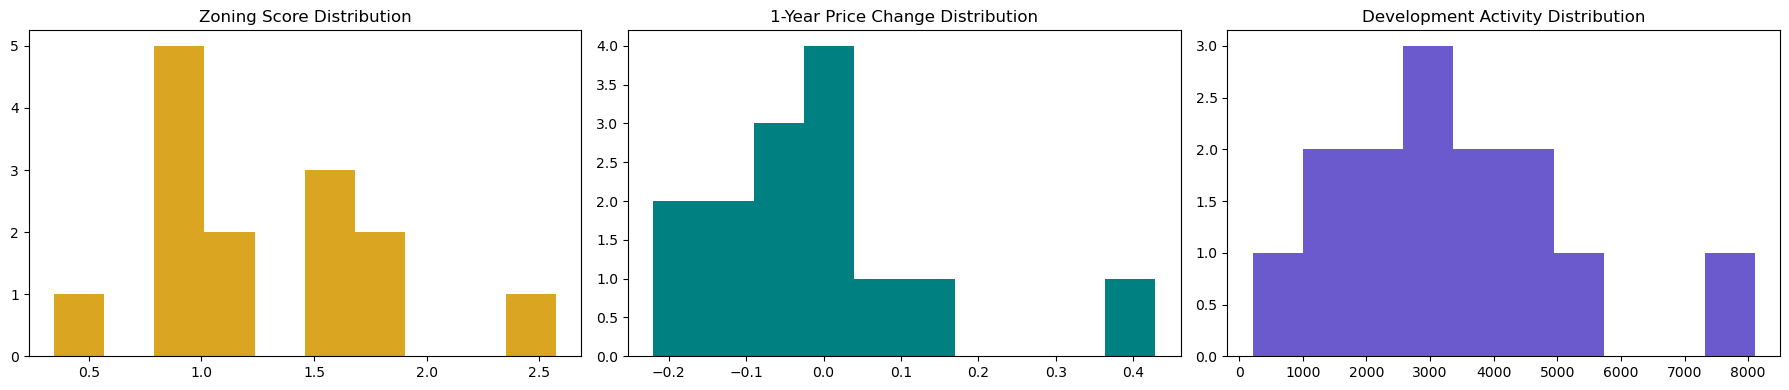

In [73]:
# Step 5b — Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(nti["ZoningScore"], bins=10, color="goldenrod")
axes[0].set_title("Zoning Score Distribution")

axes[1].hist(nti["PctChange_1yr"], bins=10, color="teal")
axes[1].set_title("1-Year Price Change Distribution")

axes[2].hist(nti["DevActivity"], bins=10, color="slateblue")
axes[2].set_title("Development Activity Distribution")

plt.tight_layout()
plt.show()

# Inspect Outliers — Results and Interpretation
### Step 5 — Inspect outliers (results)
I’m reviewing the extreme values in zoning, price change, and development activity to understand how they may influence the NTI and how they should be handled in visualization.

### Zoning Score Extremes
These neighborhoods represent the highest and lowest zoning intensity in Nashville.

High Zoning Intensity:
- Downtown — 2.575
- East Nashville — 1.8486
- North Nashville — 1.7074

Low Zoning Intensity:
- Joelton — 0.3438
- Bellevue — 0.8144
- Parkwood–Union Hill — 0.8734

Downtown is the clear zoning outlier — exactly what we expect given DTC, SP, and ORI districts.
East Nashville and North Nashville also show strong redevelopment capacity.
Joelton is a true low‑intensity outlier, which aligns with its rural/suburban zoning pattern.

### Development Activity Extremes
These neighborhoods show the highest and lowest levels of construction and pipeline activity.

High Development Activity:
- Green Hills–Midtown — 8104.9
- East Nashville — 5451.8
- Southeast — 4425.8

Low Development Activity:
- Joelton — 209.7
- Parkwood–Union Hill — 1457.9
- Bellevue — 1563.1

Green Hills–Midtown is the development activity outlier — extremely high permit and pipeline volume.
East Nashville and Southeast also show strong construction momentum.
Joelton again appears as a low‑activity outlier, consistent with its zoning profile.

### Step 5 — Summary of Outlier Behavior
What the outliers tell me

Downtown is the zoning outlier. 
Green Hills–Midtown is the development outlier. 
Parkwood–Union Hill is the price‑growth outlier. 
Joelton is consistently low across zoning, price, and development — a stable low‑intensity area.


### Step 6 — Create narrative summaries for each neighborhood
I’m generating a short, one‑line summary for every neighborhood that captures its zoning intensity, price momentum, development activity, and dominant driver.

In [74]:
# Step 6 — Create narrative summaries

nti["Summary"] = (
    "Zoning: " + nti["Zoning_norm"].round(2).astype(str) +
    ", Price: " + nti["Price_norm"].round(2).astype(str) +
    ", Dev: " + nti["Dev_norm"].round(2).astype(str) +
    ", Driver: " + nti["DominantDriver"]
)

nti[["CommunityName", "Summary"]].sort_values("CommunityName").head(10)

,CommunityName,Summary
0,Antioch - Priest Lake,"Zoning: 0.26, Price: 0.26, Dev: 0.35, Driver: ..."
1,Bellevue,"Zoning: 0.21, Price: 0.32, Dev: 0.17, Driver: ..."
2,Bordeaux - Whites Creek - Haynes Trinity,"Zoning: 0.4, Price: 0.08, Dev: 0.3, Driver: Zo..."
3,Donelson - Hermitage - Old Hickory,"Zoning: 0.31, Price: 0.19, Dev: 0.49, Driver: ..."
4,Downtown,"Zoning: 1.0, Price: 0.45, Dev: 0.52, Driver: Z..."
5,East Nashville,"Zoning: 0.67, Price: 0.28, Dev: 0.66, Driver: ..."
6,Green Hills - Midtown,"Zoning: 0.55, Price: 0.56, Dev: 1.0, Driver: D..."
7,Joelton,"Zoning: 0.0, Price: 0.12, Dev: 0.0, Driver: Pr..."
8,Madison,"Zoning: 0.27, Price: 0.34, Dev: 0.21, Driver: ..."
9,North Nashville,"Zoning: 0.61, Price: 0.31, Dev: 0.28, Driver: ..."


### Step 6b — Add Summary to the gold table
I’m ensuring the narrative summary field created in Step 6 is included in the Power BI gold table.

In [80]:
# Step 6b — Add Summary to nti_gold if missing
if "Summary" in nti.columns and "Summary" not in nti_gold.columns:
    nti_gold = nti_gold.merge(
        nti[["CommunityName", "Summary"]],
        on="CommunityName",
        how="left"
    )

nti_gold.head()

,CommunityName,ZoningScore,Zoning_norm,PctChange_1yr,Price_norm,PermitCount,ApplicationCount,DevActivity,Dev_norm,NTI,NTI_rank,Summary
0,Antioch - Priest Lake,0.920489,0.258483,-0.054496,0.255183,1941,305,2948.220064,0.346860,0.279422,11,"Zoning: 0.26, Price: 0.26, Dev: 0.35, Driver: ..."
1,Bellevue,0.814404,0.210938,-0.012715,0.319603,1208,181,1563.095909,0.171422,0.239091,13,"Zoning: 0.21, Price: 0.32, Dev: 0.17, Driver: ..."
2,Bordeaux - Whites Creek - Haynes Trinity,1.231054,0.397671,-0.166333,0.082746,1637,448,2584.053799,0.300735,0.263213,12,"Zoning: 0.4, Price: 0.08, Dev: 0.3, Driver: Zo..."
3,Donelson - Hermitage - Old Hickory,1.040629,0.312327,-0.097561,0.188783,2946,421,4043.570702,0.485596,0.312404,8,"Zoning: 0.31, Price: 0.19, Dev: 0.49, Driver: ..."
4,Downtown,2.575000,1.000000,0.073936,0.453206,1372,284,4336.829544,0.522740,0.689307,1,"Zoning: 1.0, Price: 0.45, Dev: 0.52, Driver: Z..."


In [87]:
### Add DominantDriver to nti_gold

In [88]:
# Step 6c — Add DominantDriver to nti_gold if missing
if "DominantDriver" in nti.columns and "DominantDriver" not in nti_gold.columns:
    nti_gold = nti_gold.merge(
        nti[["CommunityName", "DominantDriver"]],
        on="CommunityName",
        how="left"
    )

nti_gold.head()

,CommunityName,ZoningScore,Zoning_norm,PctChange_1yr,Price_norm,PermitCount,ApplicationCount,DevActivity,Dev_norm,NTI,NTI_rank,Summary,DominantDriver
0,Antioch - Priest Lake,0.920489,0.258483,-0.054496,0.255183,1941,305,2948.220064,0.346860,0.279422,11,"Zoning: 0.26, Price: 0.26, Dev: 0.35, Driver: ...",Dev_norm
1,Bellevue,0.814404,0.210938,-0.012715,0.319603,1208,181,1563.095909,0.171422,0.239091,13,"Zoning: 0.21, Price: 0.32, Dev: 0.17, Driver: ...",Price_norm
2,Bordeaux - Whites Creek - Haynes Trinity,1.231054,0.397671,-0.166333,0.082746,1637,448,2584.053799,0.300735,0.263213,12,"Zoning: 0.4, Price: 0.08, Dev: 0.3, Driver: Zo...",Zoning_norm
3,Donelson - Hermitage - Old Hickory,1.040629,0.312327,-0.097561,0.188783,2946,421,4043.570702,0.485596,0.312404,8,"Zoning: 0.31, Price: 0.19, Dev: 0.49, Driver: ...",Dev_norm
4,Downtown,2.575000,1.000000,0.073936,0.453206,1372,284,4336.829544,0.522740,0.689307,1,"Zoning: 1.0, Price: 0.45, Dev: 0.52, Driver: Z...",Zoning_norm


### Step 7 — Prepare fields and tables for Power BI
I’m organizing the NTI outputs into clean, ready‑to‑use structures for Power BI. This ensures each visual has a clear data source, consistent field names, and no preprocessing required inside Power BI.

In [82]:
# Step 7 — Prepare fields for Power BI visuals

# Ensure the gold table exists and is clean
nti_gold = nti_gold.sort_values("CommunityName").reset_index(drop=True)

# Prepare a separate long-format table for sale price trends
median_price_long = median_price_by_year.copy()

# Confirm structure
nti_gold.head(), median_price_long.head()

(                              CommunityName  ZoningScore  Zoning_norm  \
 0                     Antioch - Priest Lake     0.920489     0.258483   
 1                                  Bellevue     0.814404     0.210938   
 2  Bordeaux - Whites Creek - Haynes Trinity     1.231054     0.397671   
 3        Donelson - Hermitage - Old Hickory     1.040629     0.312327   
 4                                  Downtown     2.575000     1.000000   
 
    PctChange_1yr  Price_norm  PermitCount  ApplicationCount  DevActivity  \
 0      -0.054496    0.255183         1941               305  2948.220064   
 1      -0.012715    0.319603         1208               181  1563.095909   
 2      -0.166333    0.082746         1637               448  2584.053799   
 3      -0.097561    0.188783         2946               421  4043.570702   
 4       0.073936    0.453206         1372               284  4336.829544   
 
    Dev_norm       NTI  NTI_rank  \
 0  0.346860  0.279422        11   
 1  0.171422  0.23

### Step 7a — Create a clean long-format price table
I’m reshaping the median price pivot into a tidy table for Power BI line charts.

In [83]:
# Step 7a — Create long-format price table for Power BI

median_price_long = (
    median_price_by_year
    .sort_values(["CommunityName", "SaleYear"])
    .reset_index(drop=True)
)

median_price_long.head()

,CommunityName,SaleYear,MedianSalePrice
0,Antioch - Priest Lake,1974.0,35000.0
1,Antioch - Priest Lake,1975.0,29250.0
2,Antioch - Priest Lake,1976.0,34844.0
3,Antioch - Priest Lake,1977.0,38000.0
4,Antioch - Priest Lake,1978.0,40496.0


### Step 7b — Export-ready tables (optional)
If you plan to export CSVs for Power BI, these tables are ready:

In [84]:
# Step 7b — Export-ready tables (optional)
nti_gold.to_csv("nti_gold_table.csv", index=False)
median_price_long.to_csv("median_price_trends.csv", index=False)

### Step 7 — What this prepares me for

All visuals can now be built with no transformations inside Power BI.

The NTI gold table is clean, normalized, and ranked.

The price trend table is long-format and ready for line charts.

Tooltips can use the narrative summaries created in Step 6.

### Step 8 — Prepare the Power BI visuals
I’m organizing the NTI outputs into clean tables that Power BI can use directly. Each visual has a dedicated table with only the fields needed for that view, keeping the dashboard simple and consistent.

### Step 8a — Zoning Intensity Map
Step 8a — Zoning Intensity Map
I’m preparing the zoning fields needed for the zoning intensity choropleth map.
This includes zoning score, normalized zoning intensity, and the narrative summary for tooltips.

In [85]:
# Step 8a — Prepare zoning intensity fields for Power BI

zoning_map = nti_gold[[
    "CommunityName",
    "ZoningScore",
    "Zoning_norm",
    "Summary"
]].copy()

zoning_map.head()

,CommunityName,ZoningScore,Zoning_norm,Summary
0,Antioch - Priest Lake,0.920489,0.258483,"Zoning: 0.26, Price: 0.26, Dev: 0.35, Driver: ..."
1,Bellevue,0.814404,0.210938,"Zoning: 0.21, Price: 0.32, Dev: 0.17, Driver: ..."
2,Bordeaux - Whites Creek - Haynes Trinity,1.231054,0.397671,"Zoning: 0.4, Price: 0.08, Dev: 0.3, Driver: Zo..."
3,Donelson - Hermitage - Old Hickory,1.040629,0.312327,"Zoning: 0.31, Price: 0.19, Dev: 0.49, Driver: ..."
4,Downtown,2.575000,1.000000,"Zoning: 1.0, Price: 0.45, Dev: 0.52, Driver: Z..."


### Step 8b — NTI Map
I’m preparing the NTI fields needed for the NTI choropleth map.
This includes the NTI score, rank, component scores, dominant driver, and narrative summary.

In [89]:
# Step 8b — Prepare NTI fields for Power BI

nti_map = nti_gold[[
    "CommunityName",
    "NTI",
    "NTI_rank",
    "Zoning_norm",
    "Price_norm",
    "Dev_norm",
    "DominantDriver",
    "Summary"
]].copy()

nti_map.head()

,CommunityName,NTI,NTI_rank,Zoning_norm,Price_norm,Dev_norm,DominantDriver,Summary
0,Antioch - Priest Lake,0.279422,11,0.258483,0.255183,0.346860,Dev_norm,"Zoning: 0.26, Price: 0.26, Dev: 0.35, Driver: ..."
1,Bellevue,0.239091,13,0.210938,0.319603,0.171422,Price_norm,"Zoning: 0.21, Price: 0.32, Dev: 0.17, Driver: ..."
2,Bordeaux - Whites Creek - Haynes Trinity,0.263213,12,0.397671,0.082746,0.300735,Zoning_norm,"Zoning: 0.4, Price: 0.08, Dev: 0.3, Driver: Zo..."
3,Donelson - Hermitage - Old Hickory,0.312404,8,0.312327,0.188783,0.485596,Dev_norm,"Zoning: 0.31, Price: 0.19, Dev: 0.49, Driver: ..."
4,Downtown,0.689307,1,1.000000,0.453206,0.522740,Zoning_norm,"Zoning: 1.0, Price: 0.45, Dev: 0.52, Driver: Z..."


### Step 8c — Top 10 Transforming Neighborhoods (Bar Chart)
I’m preparing a filtered table of the top 10 neighborhoods by NTI.
This table supports a simple bar chart showing the strongest redevelopment pressure.

In [90]:
# Step 8c — Prepare top 10 NTI table for bar chart

top10_nti = (
    nti_gold
    .sort_values("NTI", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10_nti

,CommunityName,ZoningScore,Zoning_norm,PctChange_1yr,Price_norm,PermitCount,ApplicationCount,DevActivity,Dev_norm,NTI,NTI_rank,Summary,DominantDriver
0,Downtown,2.575000,1.000000,0.073936,0.453206,1372,284,4336.829544,0.522740,0.689307,1,"Zoning: 1.0, Price: 0.45, Dev: 0.52, Driver: Z...",Zoning_norm
1,Green Hills - Midtown,1.568289,0.548813,0.144444,0.561919,4389,925,8104.900060,1.000000,0.666197,2,"Zoning: 0.55, Price: 0.56, Dev: 1.0, Driver: D...",Dev_norm
2,East Nashville,1.848576,0.674432,-0.040067,0.277430,4034,1031,5451.826606,0.663964,0.532864,3,"Zoning: 0.67, Price: 0.28, Dev: 0.66, Driver: ...",Zoning_norm
3,West Nashville,1.640777,0.581300,0.035000,0.393172,2801,473,3878.106317,0.464639,0.486290,4,"Zoning: 0.58, Price: 0.39, Dev: 0.46, Driver: ...",Zoning_norm
4,Parkwood - Union Hill,0.873418,0.237386,0.428571,1.000000,985,131,1457.871326,0.158094,0.484478,5,"Zoning: 0.24, Price: 1.0, Dev: 0.16, Driver: P...",Price_norm
5,North Nashville,1.707361,0.611142,-0.017682,0.311944,1649,368,2448.581366,0.283576,0.424532,6,"Zoning: 0.61, Price: 0.31, Dev: 0.28, Driver: ...",Zoning_norm
6,Southeast,0.943870,0.268961,-0.044306,0.270894,3356,374,4425.767862,0.534005,0.335899,7,"Zoning: 0.27, Price: 0.27, Dev: 0.53, Driver: ...",Dev_norm
7,Donelson - Hermitage - Old Hickory,1.040629,0.312327,-0.097561,0.188783,2946,421,4043.570702,0.485596,0.312404,8,"Zoning: 0.31, Price: 0.19, Dev: 0.49, Driver: ...",Dev_norm
8,South Nashville,1.539877,0.536079,-0.220000,0.000000,1788,434,2648.411195,0.308887,0.291653,9,"Zoning: 0.54, Price: 0.0, Dev: 0.31, Driver: Z...",Zoning_norm
9,Madison,0.949843,0.271638,0.001640,0.341736,1313,220,1840.021868,0.206497,0.279887,10,"Zoning: 0.27, Price: 0.34, Dev: 0.21, Driver: ...",Price_norm


### Step 8d — Sale Price Trend Line
I’m preparing the long‑format median sale price table for the trend line visual.
This table supports a multi‑neighborhood price trend chart over time.

In [91]:
# Step 8d — Prepare long-format sale price table for Power BI

price_trend = (
    median_price_long
    .sort_values(["CommunityName", "SaleYear"])
    .reset_index(drop=True)
)

price_trend.head()

,CommunityName,SaleYear,MedianSalePrice
0,Antioch - Priest Lake,1974.0,35000.0
1,Antioch - Priest Lake,1975.0,29250.0
2,Antioch - Priest Lake,1976.0,34844.0
3,Antioch - Priest Lake,1977.0,38000.0
4,Antioch - Priest Lake,1978.0,40496.0


### Step 8e — CSV Exports
If I want to export the tables for Power BI, I can save each one as a CSV.
This step is optional but useful for keeping the dashboard reproducible. (and even if I don't use them, I want the practice)

In [93]:
# Step 8e — CSV exports for Power BI
zoning_map.to_csv("zoning_map.csv", index=False)
nti_map.to_csv("nti_map.csv", index=False)
top10_nti.to_csv("top10_nti.csv", index=False)
price_trend.to_csv("price_trend.csv", index=False)

### Fixing a mapping issue in Power BI

In [98]:
# subareas.to_file("subareas.geojson", driver="GeoJSON")

In [99]:
# subareas_4326 = subareas.to_crs(epsg=4326)

In [100]:
# geojson = json.loads(subareas_4326.to_json())

# with open("subareas_fixed.geojson", "w") as f:
#     json.dump(geojson, f)

In [102]:
# Reproject to a projected CRS for accurate centroid math
subareas_proj = subareas.to_crs(epsg=2274)

In [103]:
subareas_proj["centroid"] = subareas_proj.geometry.centroid

In [104]:
subareas_centroids = subareas_proj.set_geometry("centroid").to_crs(epsg=4326)

In [105]:
subareas_centroids["centroid_lat"] = subareas_centroids.geometry.y
subareas_centroids["centroid_lng"] = subareas_centroids.geometry.x

centroids = subareas_centroids[["CommunityName", "centroid_lat", "centroid_lng"]]
centroids.head()

,CommunityName,centroid_lat,centroid_lng
0,Parkwood - Union Hill,36.318977,-86.768262
1,Joelton,36.321748,-86.882157
2,Madison,36.268902,-86.697440
3,Bordeaux - Whites Creek - Haynes Trinity,36.226542,-86.876800
4,Donelson - Hermitage - Old Hickory,36.188677,-86.636931


In [106]:
nti_points = nti_gold.merge(centroids, on="CommunityName", how="left")

In [107]:
# New export
nti_points.to_csv("nti_points.csv", index=False)

# Executive Summary

This project develops a Neighborhood Transformation Index (NTI) for Nashville, a composite measure designed to identify which neighborhoods are experiencing the strongest redevelopment pressure. The NTI combines three independent signals—zoning intensity, sale price momentum, and development activity—to create a single, interpretable score for each neighborhood. By integrating regulatory capacity, market behavior, and construction trends, the NTI provides a balanced view of where transformation is most likely to occur.

Zoning intensity captures how much redevelopment is legally possible based on current zoning classifications. Price momentum reflects how quickly median sale prices are changing year over year, signaling shifts in demand and investment. Development activity measures the volume of building permits and pipeline projects, indicating where construction is already accelerating. Each component is normalized, combined, and ranked to produce the final NTI score.

The results highlight several clear patterns. Downtown stands out for its exceptionally high zoning intensity, while Green Hills–Midtown leads in development activity with a substantial concentration of permits and pipeline projects. Parkwood–Union Hill emerges as the strongest price‑growth outlier, showing rapid appreciation despite lower zoning intensity. In contrast, Joelton consistently ranks low across zoning, price change, and development, reflecting its stable, low‑intensity character. These patterns align with known development dynamics in Nashville and validate the NTI’s ability to capture meaningful neighborhood differences.

The NTI is designed to support planning, investment, and policy decisions by providing a clear, data‑driven view of neighborhood change. It is not a predictive model but a directional indicator that highlights where redevelopment forces are strongest today. The accompanying Power BI dashboard visualizes zoning intensity, NTI scores, top‑ranking neighborhoods, and multi‑year price trends, offering an accessible and interpretable tool for stakeholders.

# Executive Summary (Slide Version)
The Neighborhood Transformation Index (NTI) measures redevelopment pressure across Nashville by combining zoning intensity, price momentum, and development activity into a single score for each neighborhood.

Downtown, Green Hills–Midtown, and East Nashville emerge as the strongest transformation clusters, each driven by different forces: zoning capacity, construction volume, and balanced redevelopment pressure.

Parkwood–Union Hill shows the fastest price appreciation in the city, signaling rapid market change despite lower zoning intensity.

Joelton consistently ranks low across all components, reflecting stable, low‑intensity conditions with minimal redevelopment pressure.

The NTI highlights where regulatory capacity, market demand, and construction trends align—providing a clear, data‑driven view of where transformation is most likely to occur next.

(Ideas to add)
Key Findings slide, a Drivers of NTI slide, or a visual layout guide for your Power BI deck.